# Results Overview — Per-Quality Tactical Models (v4)

Per-quality OLS models for predicting how midfielder qualities change after a within-league transfer. Each quality gets its own optimal subset of team tactical dimensions, selected via exhaustive search over all 127 combinations.

---
## Model Formulation

For each player quality $i$, the predicted change after a transfer is:

$$\Delta Q_i = \alpha + \beta \cdot Q_i^{\text{pre}} + \sum_{k \in S_i} \gamma_k \cdot \Delta TQ_k$$

where:

| Symbol | Meaning |
|--------|---------|
| $\Delta Q_i$ | Change in player quality $i$ (post − pre) |
| $Q_i^{\text{pre}}$ | Player quality $i$ before the transfer |
| $\Delta TQ_k$ | Change in team tactical quality $k$ (destination − origin) |
| $S_i \subseteq \{1, \ldots, 7\}$ | Subset of team qualities selected for quality $i$ |

The subset $S_i$ is **not fixed** — it varies per player quality. For each quality, we run an
exhaustive search across all $2^7 - 1 = 127$ possible combinations of the 7 team tactical dimensions
and select the one that maximizes out-of-sample $R^2$.

**Baseline comparison**: every tactical model is benchmarked against a naive model that only
sees the pre-transfer quality ($\Delta Q_i = \alpha + \beta \cdot Q_i^{\text{pre}}$),
which captures regression to the mean but ignores tactical context entirely.

---
## Team Tactical Qualities

| Quality | Low values | High values |
|---------|-----------|-------------|
| **ATTACK** | Direct long balls | Patient build-up |
| **DEFENCE** | Compact low block | Aggressive high press |
| **OUTCOME** | Lower table | Top of table |
| **ATT. TRANSITION** | Quick counters | Controlled retention |
| **DEF. TRANSITION** | Drop back | Instant counter-press |
| **PENETRATION** | Wide crossing | Progressive carrying |
| **CHANCE CREATION** | Direct chances | Sustained possession |

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from itertools import combinations
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import warnings
warnings.filterwarnings('ignore')

# ── Design system ──
BG = '#FAFAFA'; GRID = '#EDEDED'; AXIS = '#D5D5D5'
TEXT = '#2D2D2D'; SUBTEXT = '#737373'
C_PRE = '#5D6D7E'; C_POST = '#1A9C6E'
C_BASELINE = '#BF5B3F'; C_TACTICAL = '#2E74B5'
C_POP = '#C8DCC0'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SUBTEXT,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlepad': 16,
    'axes.labelsize': 9.5, 'axes.grid': False,
    'text.color': TEXT, 'xtick.color': SUBTEXT, 'ytick.color': SUBTEXT,
    'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'font.family': 'sans-serif', 'figure.dpi': 140,
    'axes.spines.top': False, 'axes.spines.right': False,
})

def add_subtitle(ax, text, y=1.02):
    ax.text(0, y, text, transform=ax.transAxes,
            fontsize=9, color=SUBTEXT, style='italic')

In [2]:
DATA_DIR = "../../../thesis_data/processed_data/thesis_model_dataset/active/"
RAW_DIR  = "../../../thesis_data/raw_data/"
df = pd.read_parquet(DATA_DIR + "within_league_transfers_v5.parquet")
mf = df[df["from_position"] == "Midfielder"].copy()

teams = pd.read_parquet(RAW_DIR + "Wyscout/wyscout_teams.parquet")
team_map = dict(zip(teams['team_id'], teams['name']))

QUALITIES = [
    "Involvement", "Active defence", "Intelligent defence", "Progression",
    "Passing quality", "Effectiveness", "Providing teammates", "Box threat",
]

TQ_NAMES = ["ATTACK", "ATTACKING_TRANSITION", "CHANCE_CREATION",
            "DEFENCE", "DEFENSIVE_TRANSITION", "OUTCOME", "PENETRATION"]

for q in QUALITIES:
    mf['delta_' + q] = mf['to_' + q] - mf['from_' + q]

for tq in TQ_NAMES:
    mf['delta_tq_' + tq] = mf['to_q_' + tq] - mf['from_q_proj_' + tq]

delta_tq = ['delta_tq_' + tq for tq in TQ_NAMES]
cols_needed = ['from_' + q for q in QUALITIES] + ['delta_' + q for q in QUALITIES] + delta_tq
mf = mf.dropna(subset=cols_needed)

train, test = train_test_split(mf, test_size=0.2, random_state=42)
print('Midfielders: {:,}  (train: {:,}, test: {:,})'.format(len(mf), len(train), len(test)))

Midfielders: 4,888  (train: 3,910, test: 978)


---
## Exhaustive Search — All 8 Qualities

In [3]:
# Run baseline + exhaustive search for each quality
summary_rows = []
best_models = {}

for q in QUALITIES:
    y_train = train['delta_' + q]
    y_test  = test['delta_' + q]

    # Naive
    X_tr = sm.add_constant(train[['from_' + q]])
    X_te = sm.add_constant(test[['from_' + q]])
    naive = sm.OLS(y_train, X_tr).fit()
    naive_pred = naive.predict(X_te)
    naive_r2  = r2_score(y_test, naive_pred)
    naive_mae = mean_absolute_error(y_test, naive_pred)

    # Exhaustive
    best_r2 = -999
    best_combo = None
    best_model = None
    best_pred = None

    for k in range(1, 8):
        for combo in combinations(delta_tq, k):
            feat = ['from_' + q] + list(combo)
            X_tr = sm.add_constant(train[feat])
            X_te = sm.add_constant(test[feat])
            m = sm.OLS(y_train, X_tr).fit()
            pred = m.predict(X_te)
            r2 = r2_score(y_test, pred)
            if r2 > best_r2:
                best_r2 = r2
                best_combo = [c.replace('delta_tq_', '') for c in combo]
                best_model = m
                best_pred = pred
                best_mae_val = mean_absolute_error(y_test, pred)

    r2_pct = (best_r2 - naive_r2) / abs(naive_r2) * 100 if naive_r2 != 0 else 0

    summary_rows.append({
        'Quality': q,
        'Naive R2': naive_r2,
        'Naive MAE': naive_mae,
        'Tactical R2': best_r2,
        'Tactical MAE': best_mae_val,
        'R2 gain': best_r2 - naive_r2,
        'R2 gain %': r2_pct,
        'MAE reduction': naive_mae - best_mae_val,
        'Selected deltas': ', '.join(best_combo),
        'N deltas': len(best_combo),
    })

    best_models[q] = {
        'naive': naive, 'naive_pred': naive_pred,
        'tactical': best_model, 'tactical_pred': best_pred,
        'deltas': best_combo,
    }

    print('{:<22} Naive R2={:.4f}  Tactical R2={:.4f}  Gain={:+.4f} ({:+.1f}%)  Deltas: {}'.format(
        q, naive_r2, best_r2, best_r2 - naive_r2, r2_pct, ', '.join(best_combo)))

summary = pd.DataFrame(summary_rows)

Involvement            Naive R2=0.2076  Tactical R2=0.3294  Gain=+0.1218 (+58.7%)  Deltas: ATTACK, ATTACKING_TRANSITION, DEFENCE, DEFENSIVE_TRANSITION, OUTCOME
Active defence         Naive R2=0.2276  Tactical R2=0.2361  Gain=+0.0085 (+3.7%)  Deltas: DEFENCE, OUTCOME
Intelligent defence    Naive R2=0.2340  Tactical R2=0.2494  Gain=+0.0154 (+6.6%)  Deltas: CHANCE_CREATION, DEFENCE, DEFENSIVE_TRANSITION, OUTCOME
Progression            Naive R2=0.1953  Tactical R2=0.2138  Gain=+0.0185 (+9.5%)  Deltas: ATTACK, ATTACKING_TRANSITION, DEFENCE, DEFENSIVE_TRANSITION
Passing quality        Naive R2=0.1848  Tactical R2=0.2472  Gain=+0.0624 (+33.8%)  Deltas: ATTACK, DEFENCE, DEFENSIVE_TRANSITION, OUTCOME
Effectiveness          Naive R2=0.2514  Tactical R2=0.2921  Gain=+0.0407 (+16.2%)  Deltas: ATTACK, ATTACKING_TRANSITION, DEFENCE, OUTCOME, PENETRATION
Providing teammates    Naive R2=0.2054  Tactical R2=0.2412  Gain=+0.0358 (+17.4%)  Deltas: ATTACK, DEFENCE, OUTCOME
Box threat             Naive R2=

---
## Results Overview

In [4]:
display_cols = ['Quality', 'Naive R2', 'Tactical R2', 'R2 gain', 'R2 gain %',
                'Naive MAE', 'Tactical MAE', 'N deltas', 'Selected deltas']
print(summary[display_cols].to_string(index=False, float_format='{:.4f}'.format))

            Quality  Naive R2  Tactical R2  R2 gain  R2 gain %  Naive MAE  Tactical MAE  N deltas                                                      Selected deltas
        Involvement    0.2076       0.3294   0.1218    58.6987     0.3730        0.3430         5 ATTACK, ATTACKING_TRANSITION, DEFENCE, DEFENSIVE_TRANSITION, OUTCOME
     Active defence    0.2276       0.2361   0.0085     3.7346     0.4386        0.4360         2                                                     DEFENCE, OUTCOME
Intelligent defence    0.2340       0.2494   0.0154     6.5649     0.4749        0.4704         4              CHANCE_CREATION, DEFENCE, DEFENSIVE_TRANSITION, OUTCOME
        Progression    0.1953       0.2138   0.0185     9.4864     0.4680        0.4638         4          ATTACK, ATTACKING_TRANSITION, DEFENCE, DEFENSIVE_TRANSITION
    Passing quality    0.1848       0.2472   0.0624    33.7830     0.4081        0.3933         4                       ATTACK, DEFENCE, DEFENSIVE_TRANSITION, OUTCOM

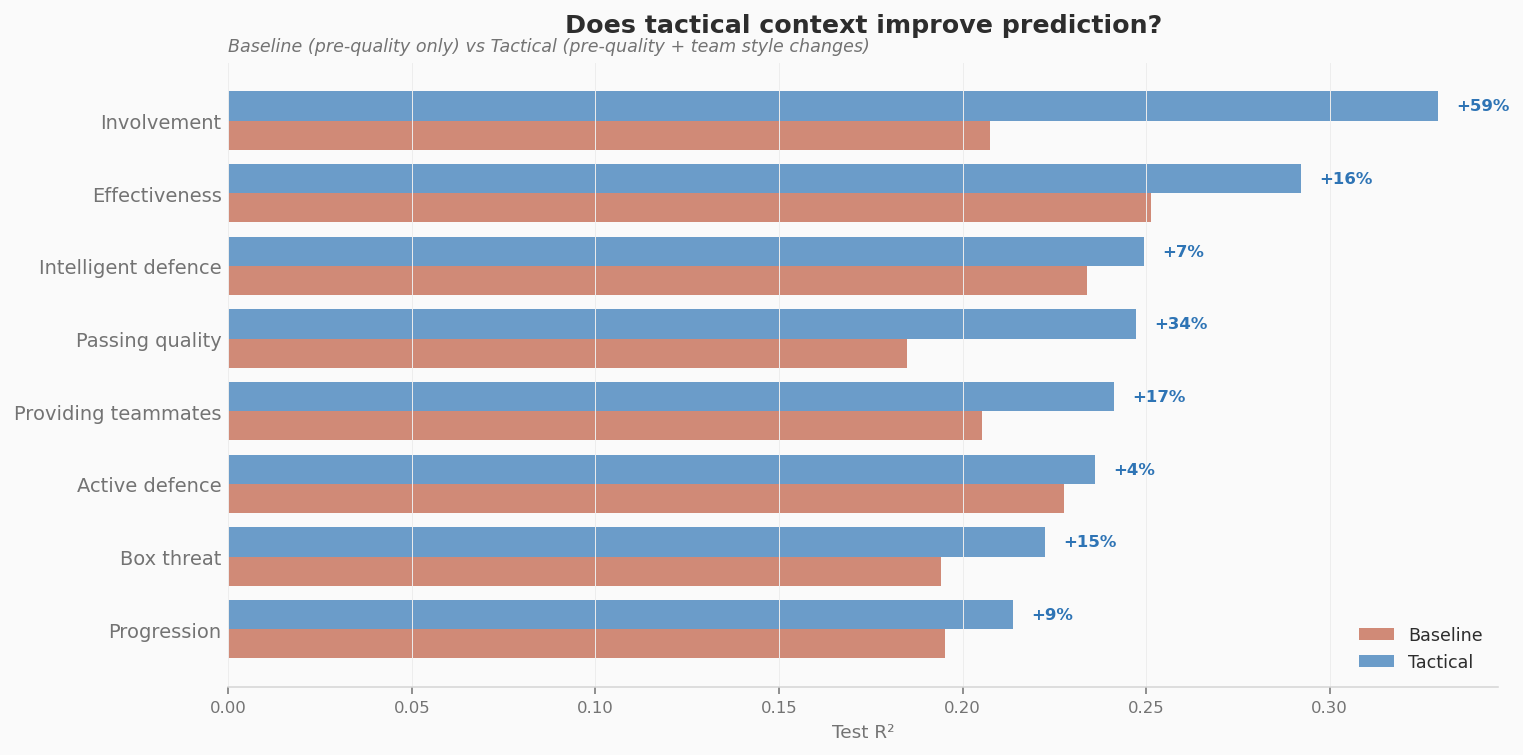

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

sorted_df = summary.sort_values('Tactical R2', ascending=True).reset_index(drop=True)
y = range(len(sorted_df))

ax.barh(list(y), sorted_df['Naive R2'].values,
        height=0.4, color=C_BASELINE, alpha=0.7, label='Baseline')
ax.barh([i + 0.4 for i in y], sorted_df['Tactical R2'].values,
        height=0.4, color=C_TACTICAL, alpha=0.7, label='Tactical')

# Add % improvement
for i, (_, row) in enumerate(sorted_df.iterrows()):
    ax.text(row['Tactical R2'] + 0.005, i + 0.4, '+{:.0f}%'.format(row['R2 gain %']),
            va='center', ha='left', fontsize=8.5, fontweight='bold', color=C_TACTICAL)

ax.set_yticks([i + 0.2 for i in y])
ax.set_yticklabels(sorted_df['Quality'].values, fontsize=10)
ax.set_xlabel('Test R²')
ax.set_title('Does tactical context improve prediction?')
add_subtitle(ax, 'Baseline (pre-quality only) vs Tactical (pre-quality + team style changes)')
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.grid(axis='x', color=GRID, linewidth=0.5)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)
plt.tight_layout()
plt.show()

---
## Which team qualities matter for each player quality?

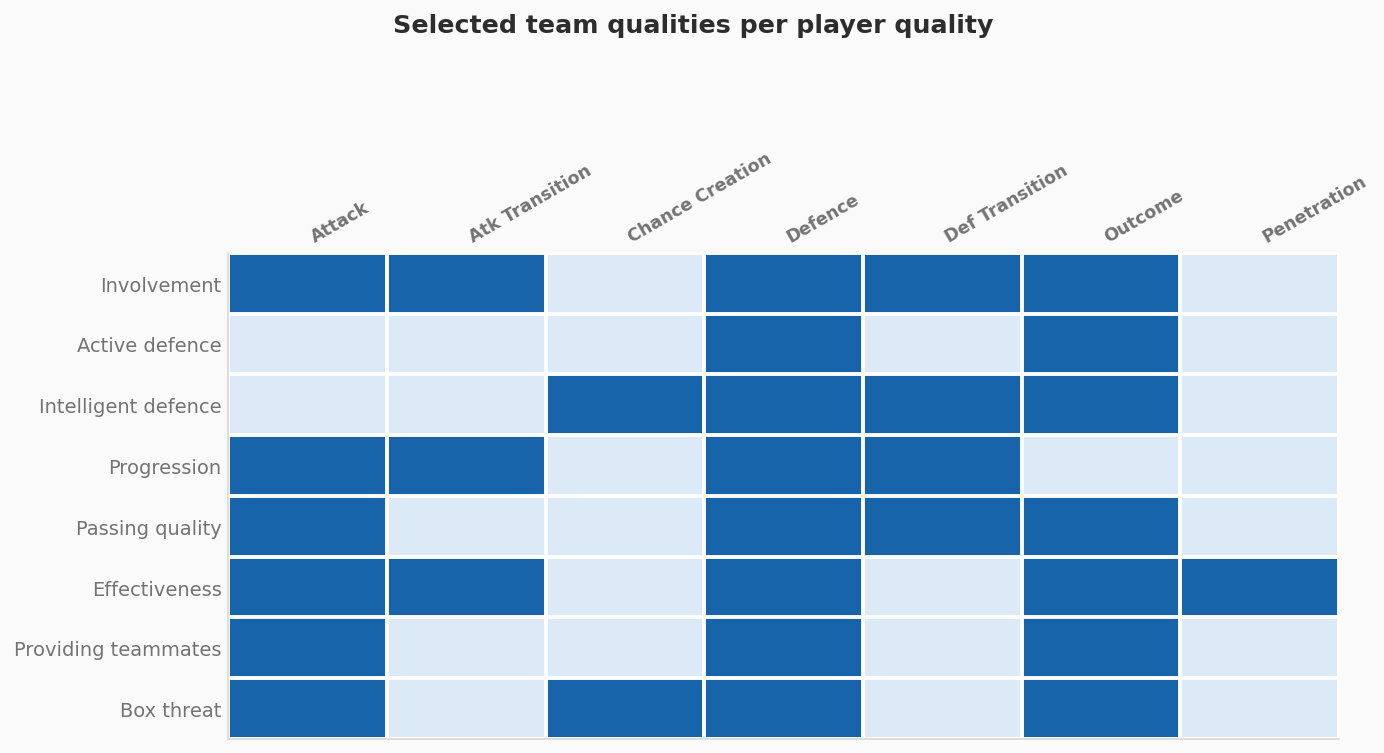

In [6]:
# Build selection matrix
tq_full = ['Attack', 'Atk Transition', 'Chance Creation',
           'Defence', 'Def Transition', 'Outcome', 'Penetration']
matrix = []
for _, row in summary.iterrows():
    selected = row['Selected deltas'].split(', ')
    matrix.append([1 if tq in selected else 0 for tq in TQ_NAMES])

mat_df = pd.DataFrame(matrix, index=summary['Quality'], columns=tq_full)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.subplots_adjust(top=0.85)
im = ax.imshow(mat_df.values, cmap='Blues', aspect='auto', vmin=-0.2, vmax=1.3)

ax.set_xticks(range(len(tq_full)))
ax.set_xticklabels(tq_full, fontsize=9, fontweight='bold', rotation=30, ha='left')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', pad=4)
ax.set_yticks(range(len(QUALITIES)))
ax.set_yticklabels(summary['Quality'].values, fontsize=10)
ax.tick_params(axis='both', length=0)

for i in range(len(QUALITIES) + 1):
    ax.axhline(i - 0.5, color='white', linewidth=2)
for j in range(len(tq_full) + 1):
    ax.axvline(j - 0.5, color='white', linewidth=2)

fig.suptitle('Selected team qualities per player quality', fontsize=13,
             fontweight='bold', y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

In [7]:
# How often is each team quality selected?
counts = mat_df.sum().sort_values(ascending=False)
print('Team quality selection frequency (out of 8):')
print(counts.to_string())

Team quality selection frequency (out of 8):
Defence            8
Outcome            7
Attack             6
Def Transition     4
Atk Transition     3
Chance Creation    2
Penetration        1


---
## Case Studies

For each player: tactical context (team quality deltas) and player quality profile (radar).
Showing pre-transfer, actual post-transfer, and tactical model prediction.

In [8]:
CASE_STUDIES = {
    379209: 'Declan Rice',
    69404:  'Mateo Kovacic',
    54:     'Christian Eriksen',
    86195:  'Miralem Pjanic',
    7899:   'Oriol Romeu',
}

ALL_TQ = ['ATTACK', 'ATTACKING_TRANSITION', 'CHANCE_CREATION',
          'DEFENCE', 'DEFENSIVE_TRANSITION', 'OUTCOME', 'PENETRATION']

TQ_DISPLAY = ['Attack', 'Atk Transition', 'Chance Creation',
              'Defence', 'Def Transition', 'Outcome', 'Penetration']

STYLE_LABELS = {
    'ATTACK':              ('Direct',        'Build-up'),
    'ATTACKING_TRANSITION': ('Counter',       'Retention'),
    'CHANCE_CREATION':     ('Direct',         'Sustained'),
    'DEFENCE':             ('Low block',      'High press'),
    'DEFENSIVE_TRANSITION': ('Drop back',     'Counter-press'),
    'OUTCOME':             ('Lower table',    'Top table'),
    'PENETRATION':         ('Crossing',       'Carrying'),
}

In [9]:
def radar_chart(ax, labels, pre, post, pred_tact, pred_base, title=''):
    n = len(labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    pre_v  = list(pre) + [pre[0]]
    post_v = list(post) + [post[0]]
    tact_v = list(pred_tact) + [pred_tact[0]]
    base_v = list(pred_base) + [pred_base[0]]

    ax.set_facecolor(BG)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8, fontweight='bold', color=TEXT)
    ax.tick_params(axis='x', pad=15)

    all_vals = list(pre) + list(post) + list(pred_tact) + list(pred_base)
    lo = min(min(all_vals) - 0.15, -0.5)
    hi = max(max(all_vals) + 0.15, 0.5)
    ax.set_ylim(lo, hi)

    tick_vals = [round(t, 1) for t in np.arange(np.ceil(lo * 5) / 5, hi, 0.2)]
    ax.set_yticks(tick_vals)
    ax.set_yticklabels(['{:.1f}'.format(t) for t in tick_vals], fontsize=6.5, color=SUBTEXT)
    ax.spines['polar'].set_color(GRID)
    ax.grid(color=GRID, linewidth=0.5)

    # Pre-transfer
    ax.plot(angles, pre_v, 'o-', color=C_PRE, linewidth=1.5,
            markersize=4, label='Pre-transfer', zorder=3)
    ax.fill(angles, pre_v, color=C_PRE, alpha=0.06)

    # Baseline prediction
    ax.plot(angles, base_v, 'D--', color=C_BASELINE, linewidth=1.2,
            markersize=3.5, label='Baseline pred', zorder=3, alpha=0.8)

    # Tactical prediction
    ax.plot(angles, tact_v, 'D-', color=C_TACTICAL, linewidth=1.5,
            markersize=4, label='Tactical pred', zorder=4)
    ax.fill(angles, tact_v, color=C_TACTICAL, alpha=0.06)

    # Actual post
    ax.plot(angles, post_v, 'o-', color=C_POST, linewidth=1.8,
            markersize=5, label='Actual post', zorder=5)
    ax.fill(angles, post_v, color=C_POST, alpha=0.08)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=25)

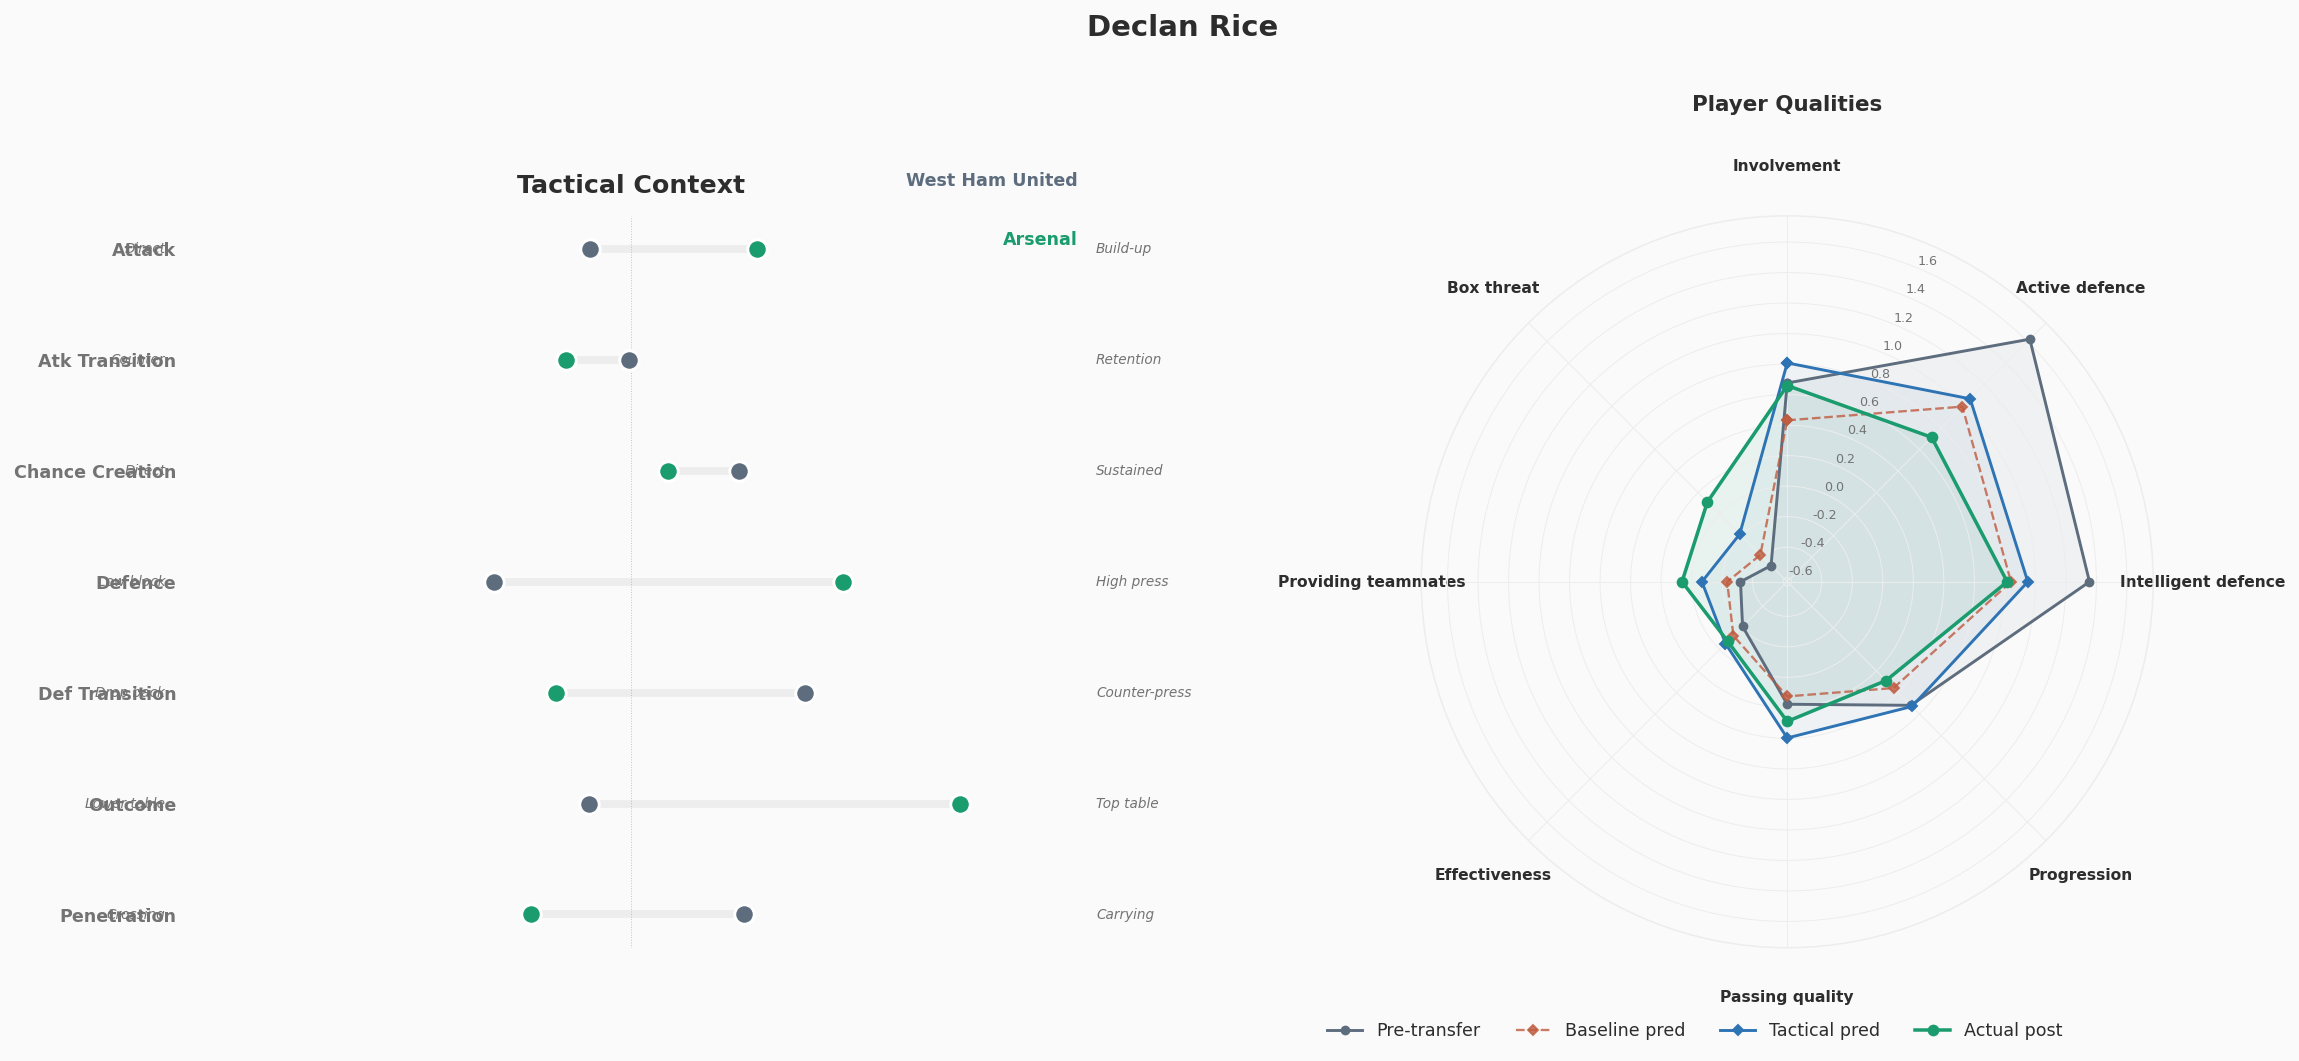

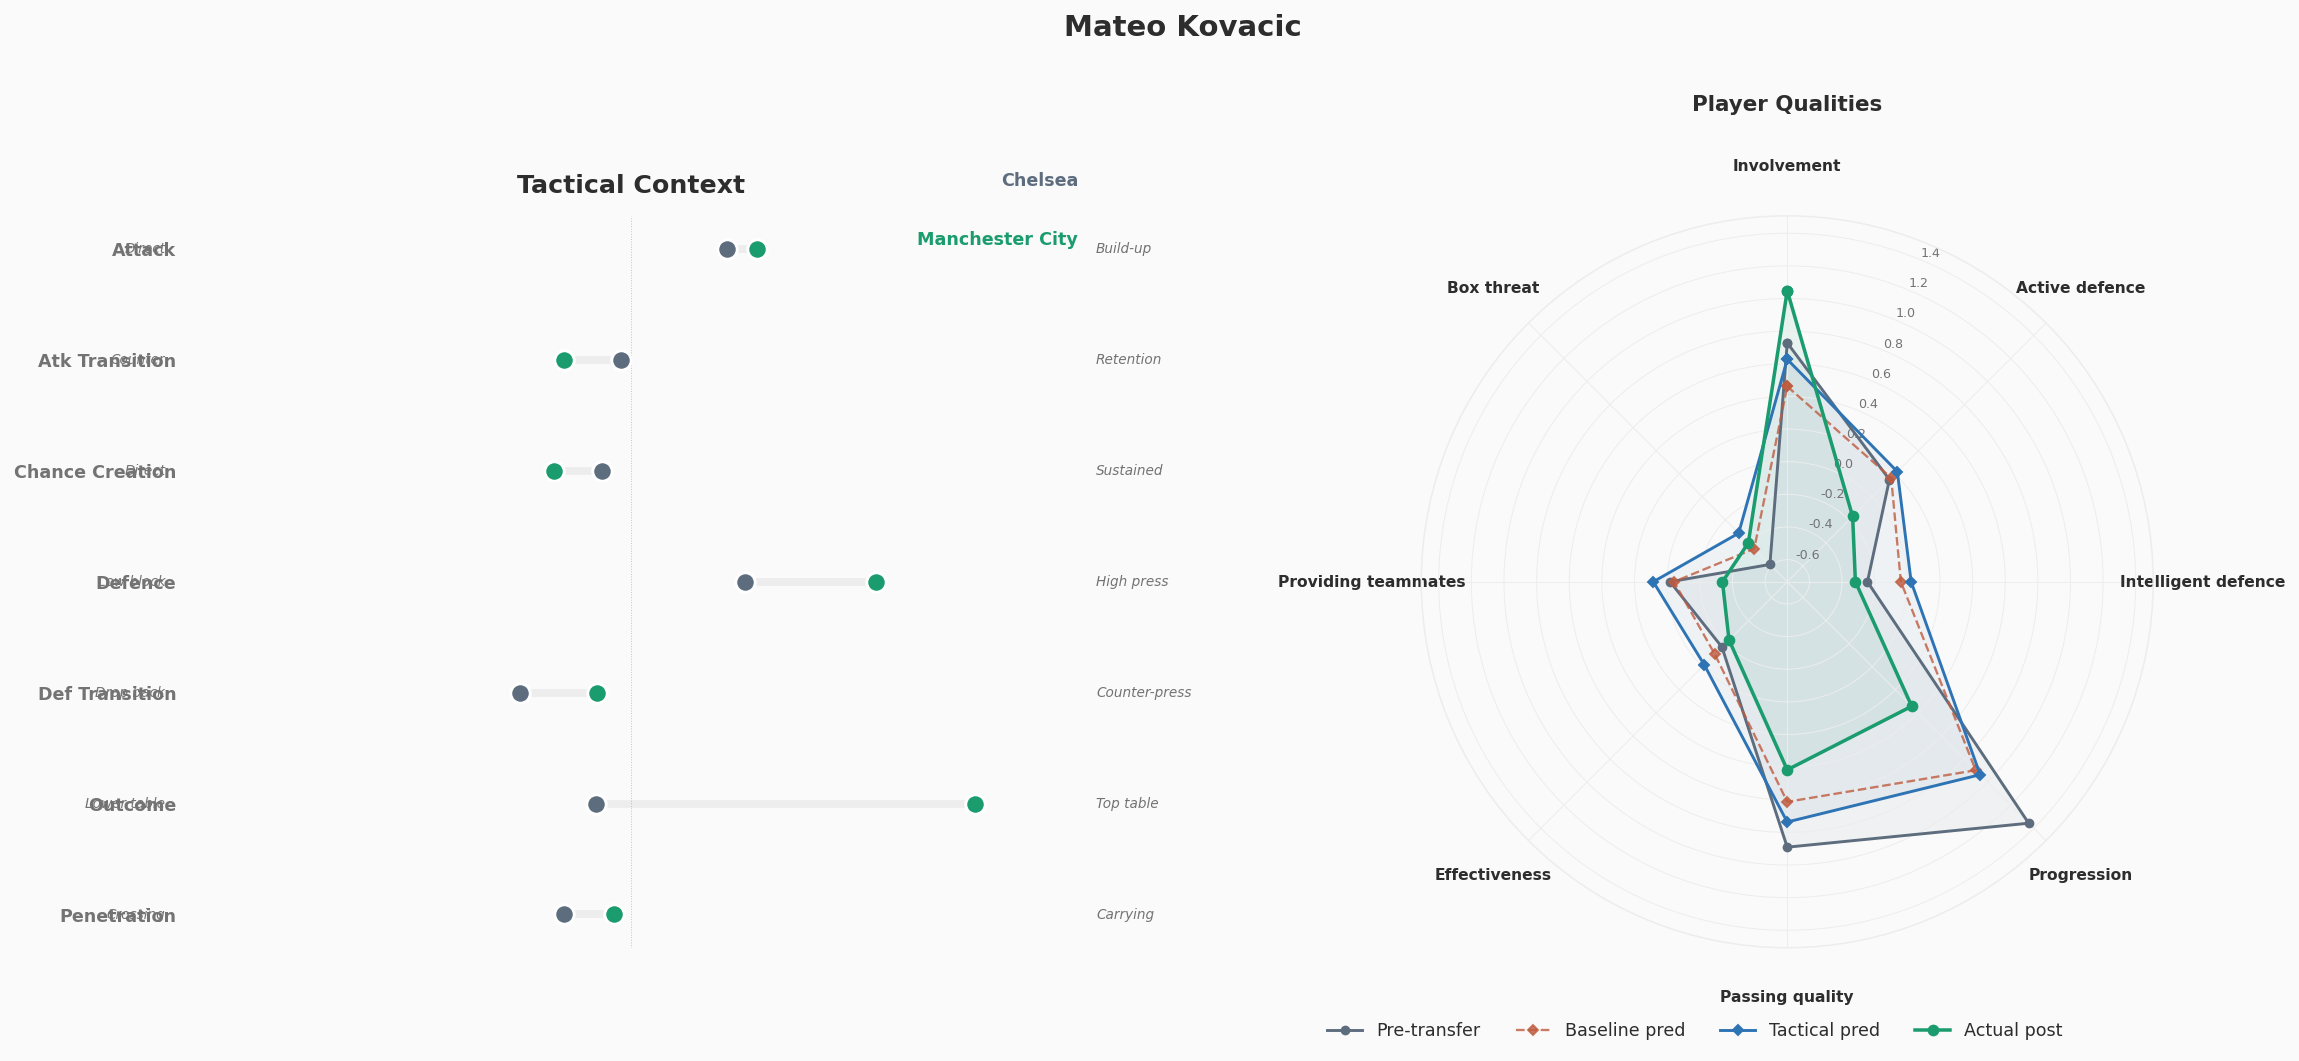

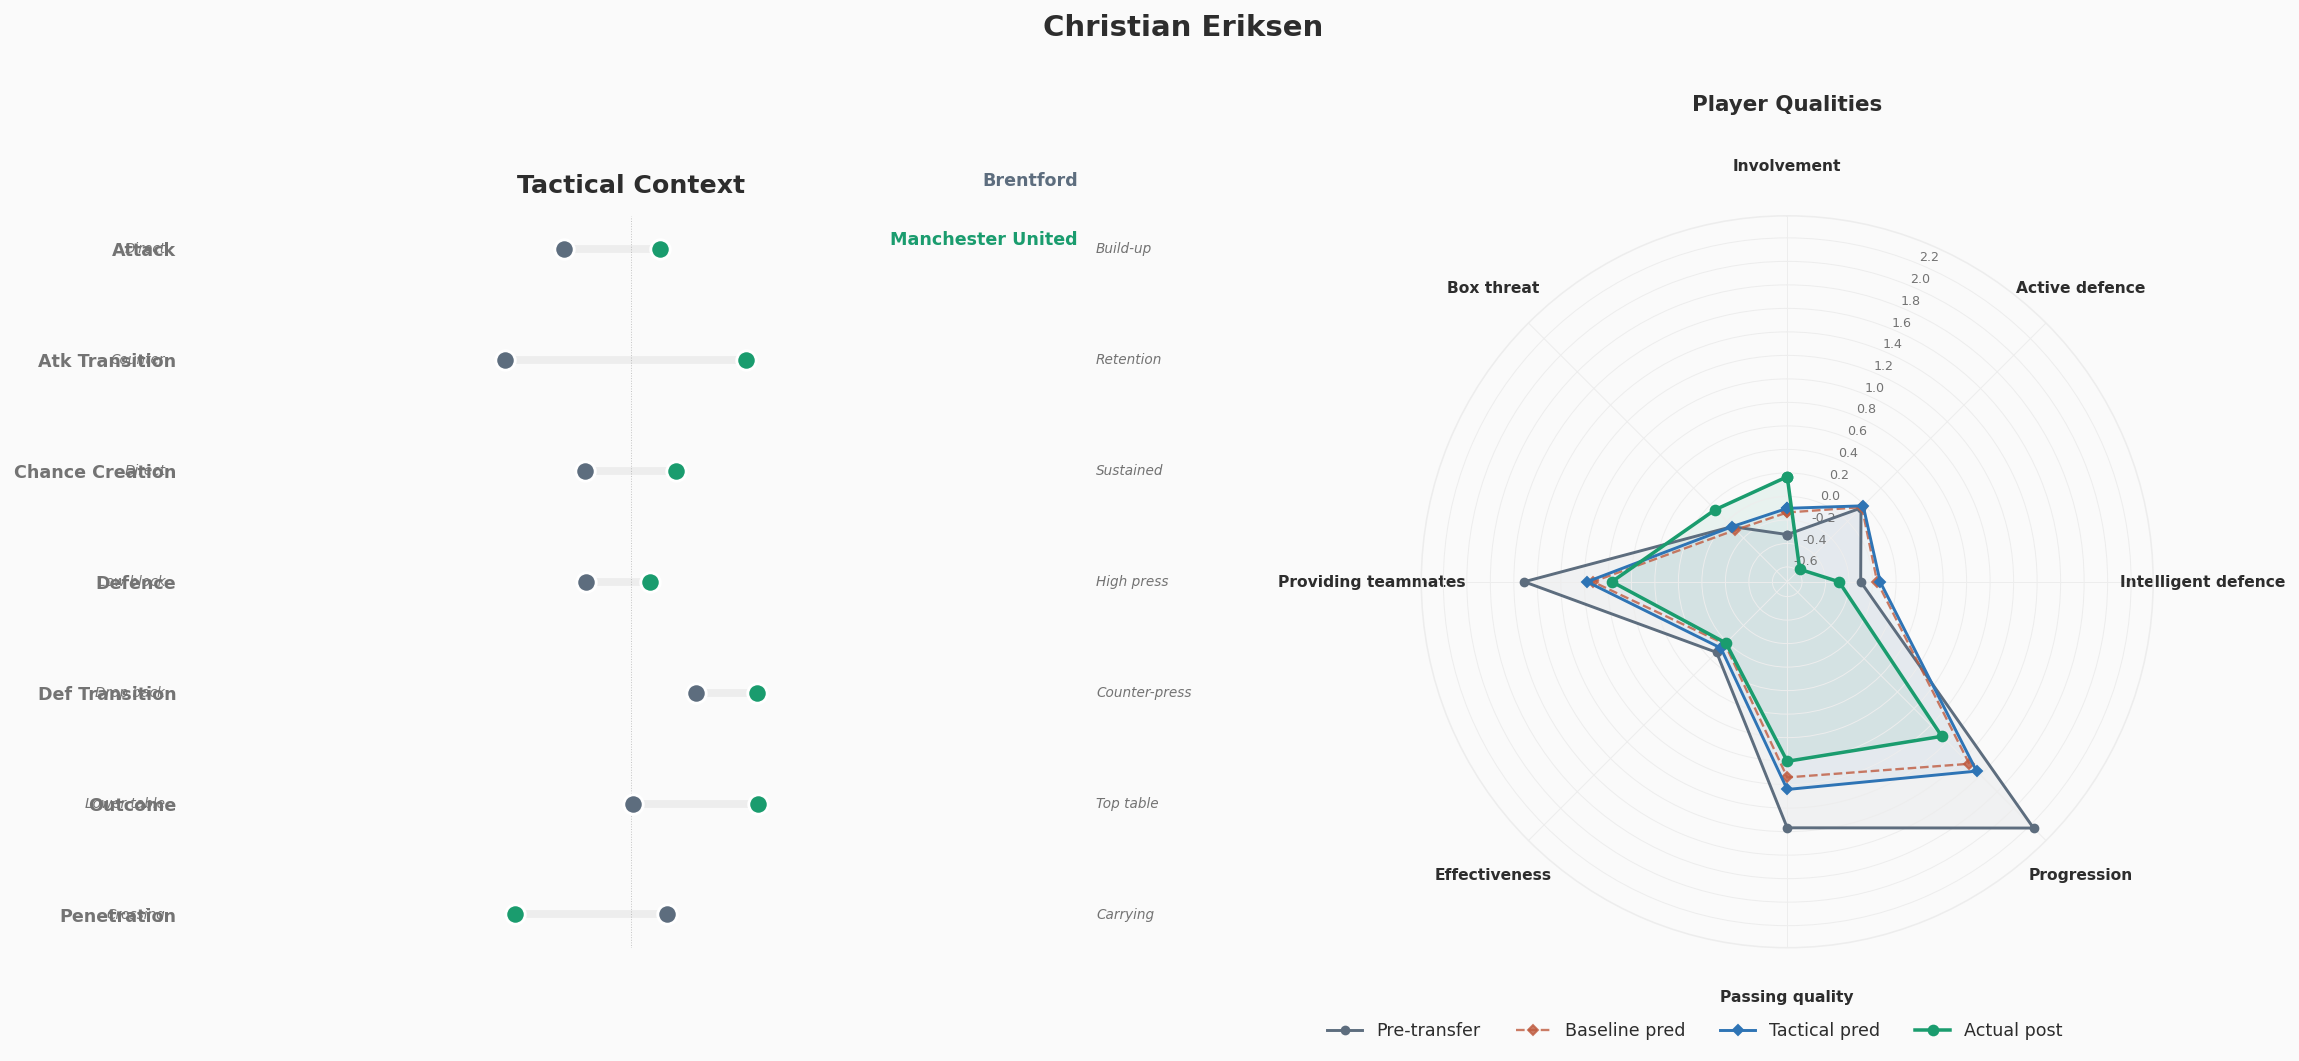

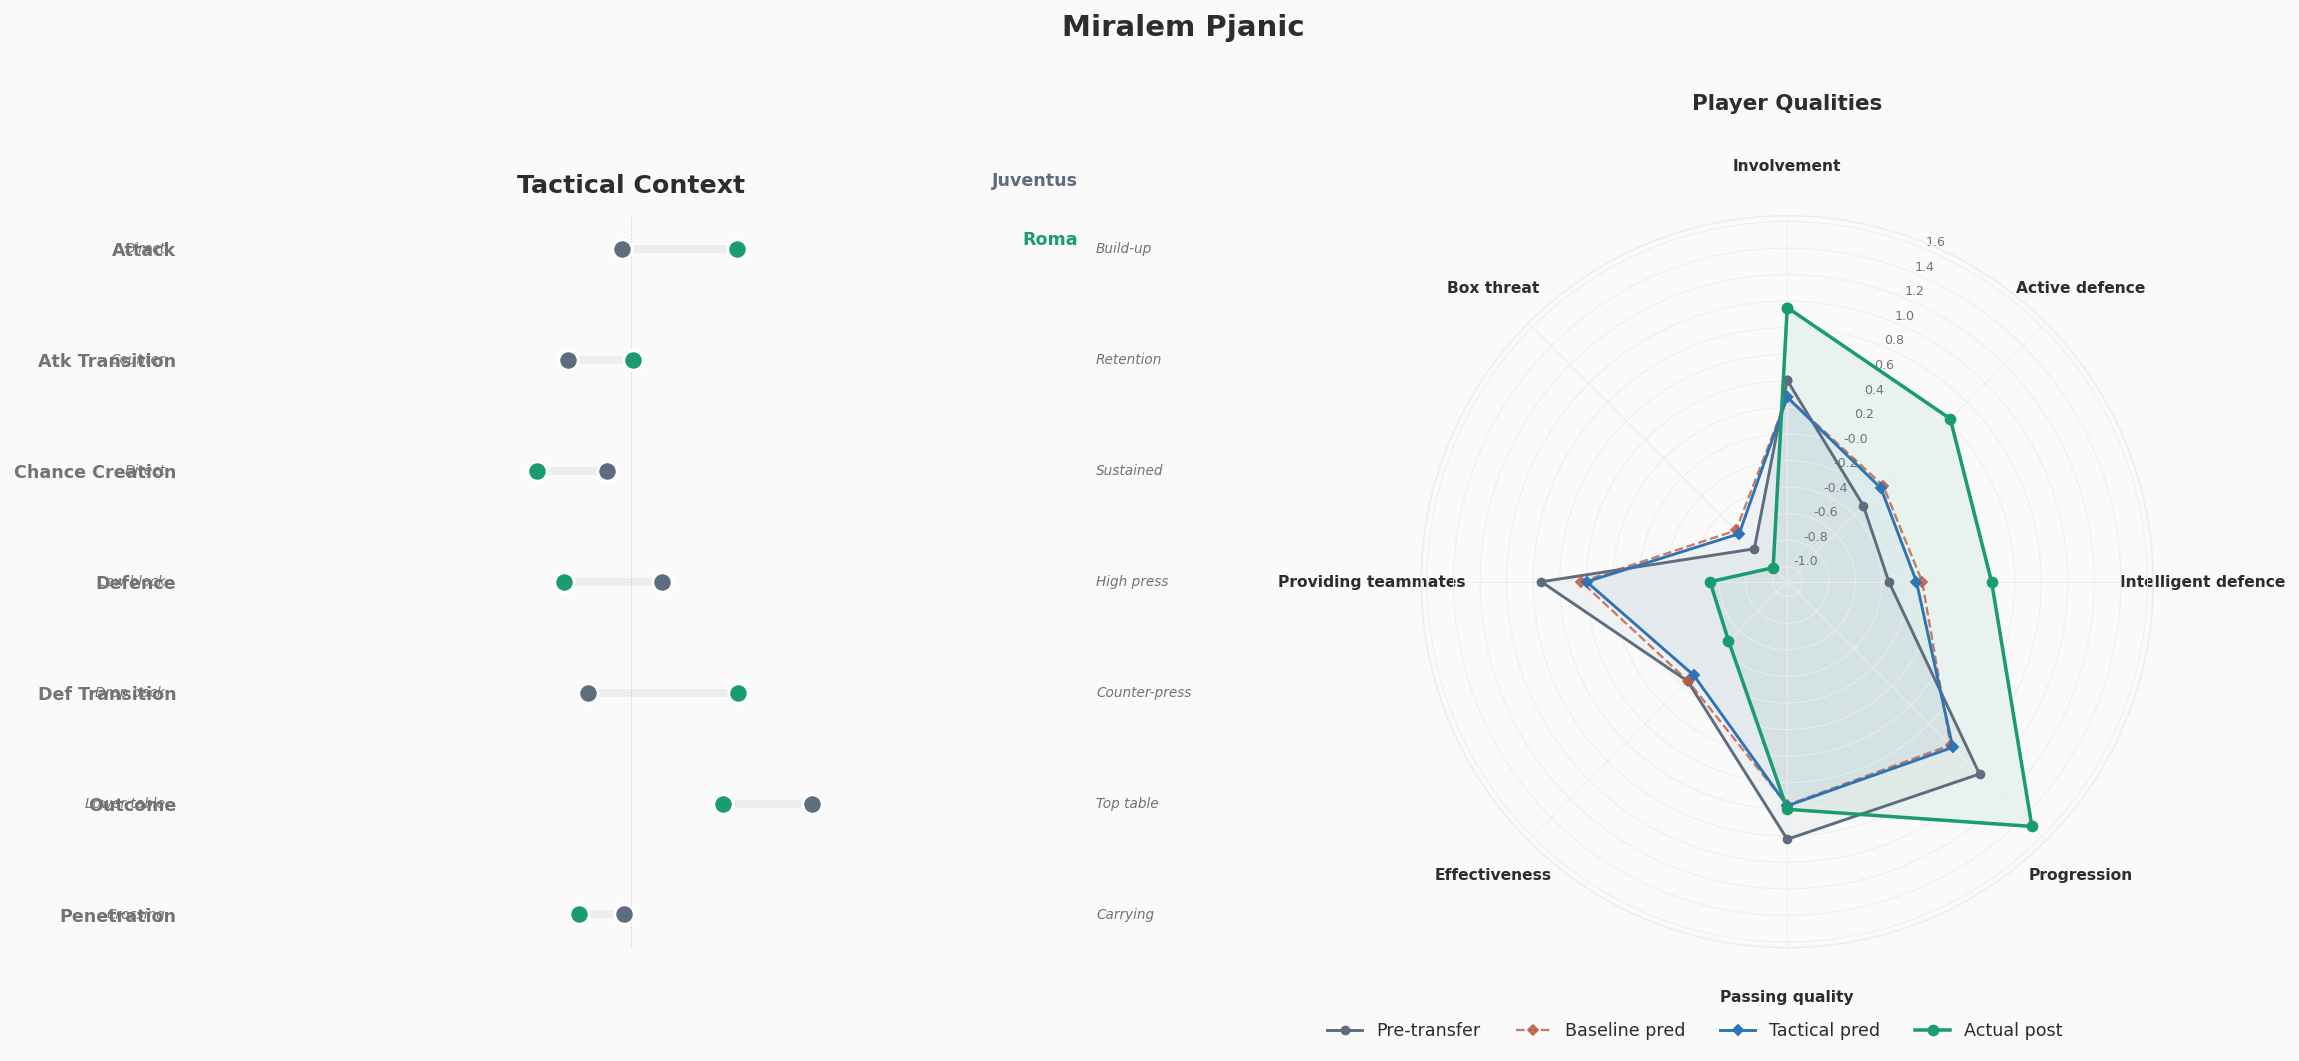

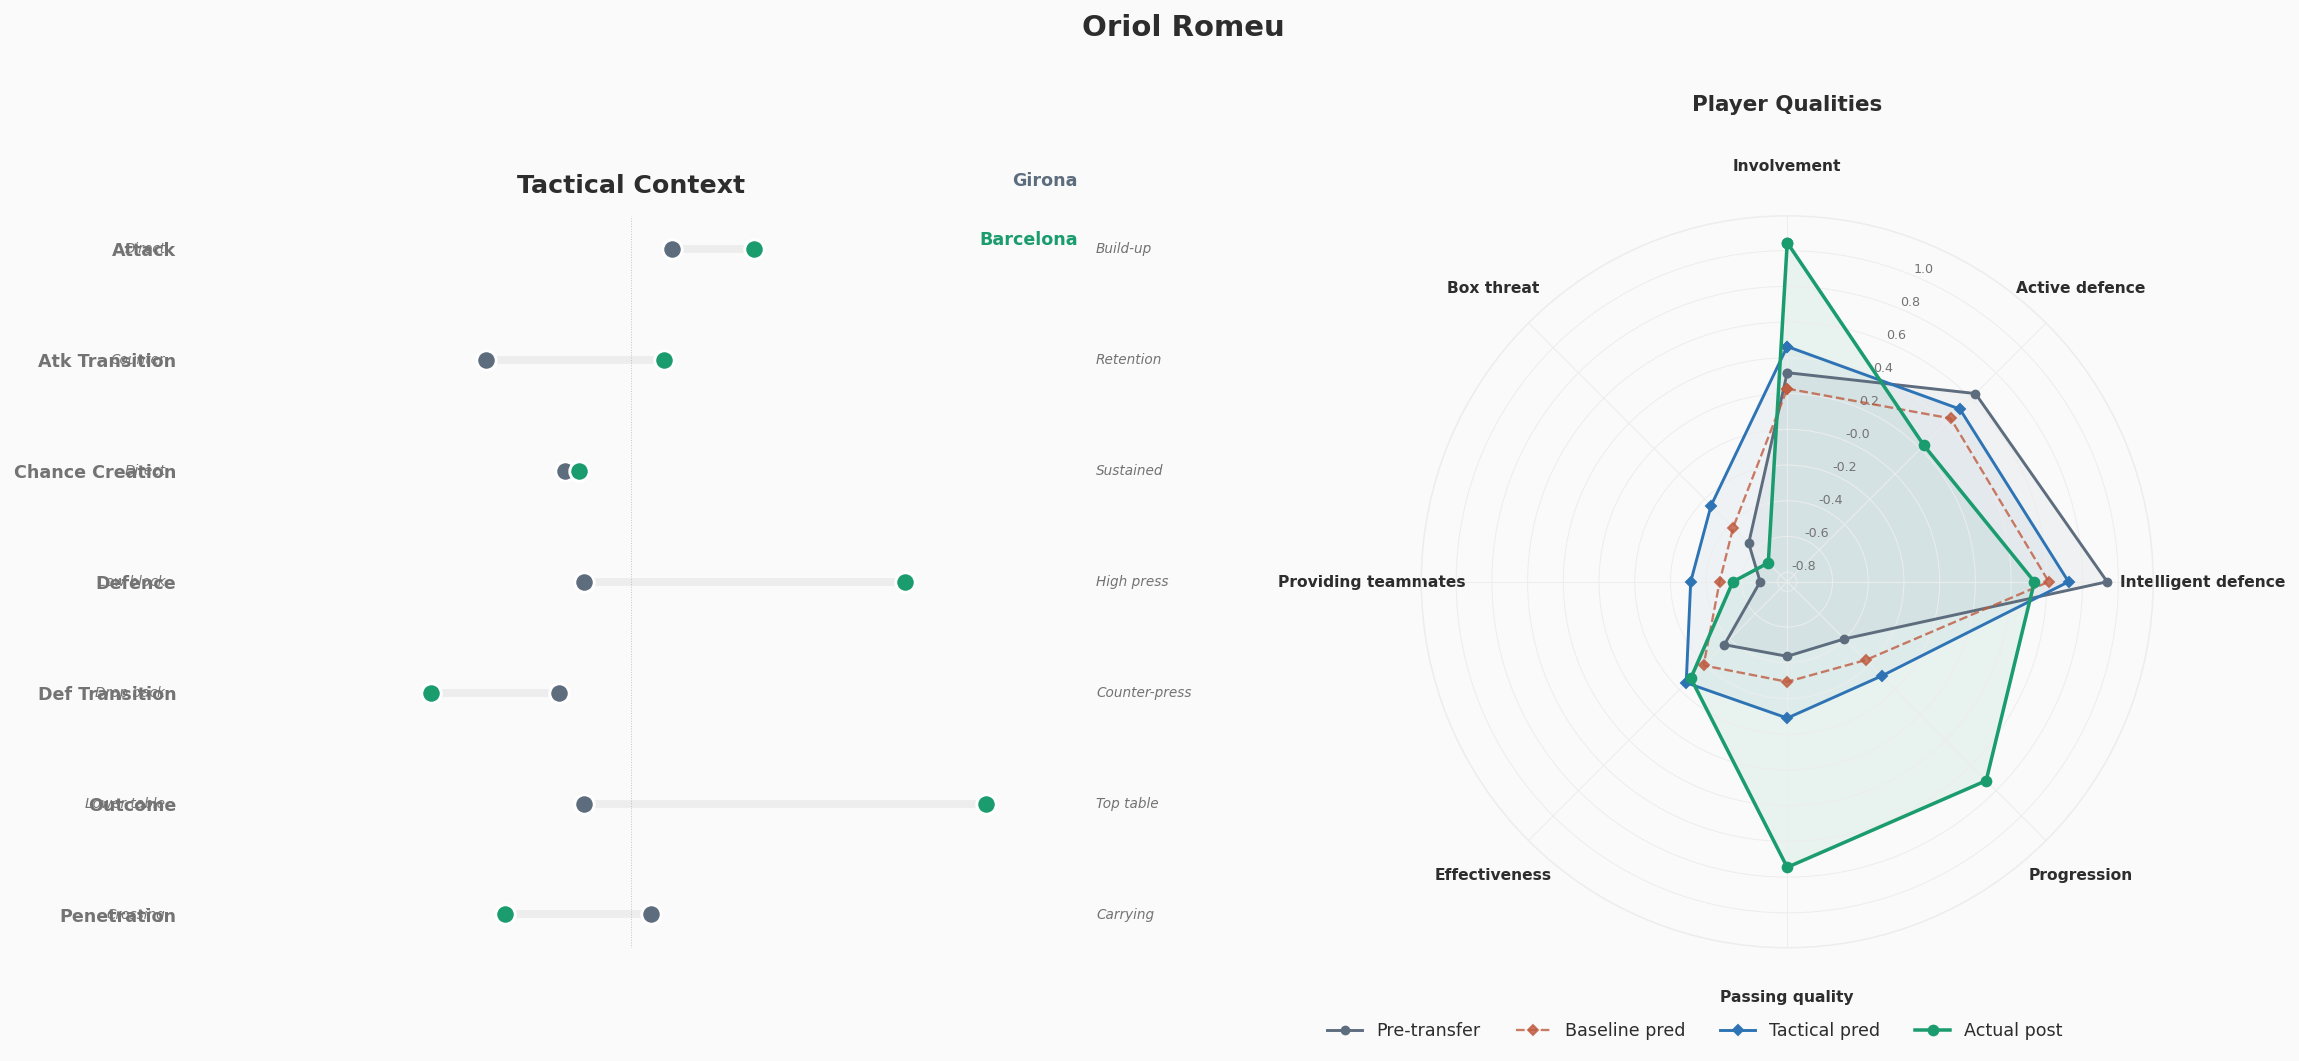

In [10]:
for pid, name in CASE_STUDIES.items():
    row = mf[mf['wy_player_id'] == pid]
    if len(row) == 0:
        print('Not found: ' + name)
        continue
    row = row.iloc[0]
    from_team = team_map.get(row['from_team_id'], '?')
    to_team   = team_map.get(row['to_team_id'], '?')

    # ── Compute predictions for all 8 qualities ──
    pre_vals = []
    post_vals = []
    base_vals = []
    tact_vals = []

    for q in QUALITIES:
        bm = best_models[q]
        pre_v  = row['from_' + q]
        post_v = row['to_' + q]

        # Baseline
        nx = pd.DataFrame({'const': [1.0], 'from_' + q: [pre_v]})
        pred_n = bm['naive'].predict(nx)[0]

        # Tactical
        td = {'const': [1.0], 'from_' + q: [pre_v]}
        for d in bm['deltas']:
            td['delta_tq_' + d] = [row['delta_tq_' + d]]
        tx = pd.DataFrame(td)
        pred_t = bm['tactical'].predict(tx)[0]

        pre_vals.append(pre_v)
        post_vals.append(post_v)
        base_vals.append(pre_v + pred_n)
        tact_vals.append(pre_v + pred_t)

    # ═══════════════════════════════════════════
    fig = plt.figure(figsize=(17, 7.5))
    fig.suptitle(name, fontsize=15, fontweight='bold', y=1.01)

    # ── LEFT: Tactical context ──
    ax1 = fig.add_subplot(121)

    for i, tq in enumerate(ALL_TQ):
        fr = row['from_q_proj_' + tq]
        to = row['to_q_' + tq]
        ax1.plot([fr, to], [i, i], color=GRID, linewidth=4, solid_capstyle='round', zorder=1)
        ax1.scatter(fr, i, color=C_PRE, s=100, zorder=3, edgecolors='white', linewidth=1.5)
        ax1.scatter(to, i, color=C_POST, s=100, zorder=3, edgecolors='white', linewidth=1.5)

    for i, tq in enumerate(ALL_TQ):
        left, right = STYLE_LABELS[tq]
        ax1.text(-2.6, i, left, ha='right', va='center', fontsize=7, color=SUBTEXT, style='italic')
        ax1.text(2.6, i, right, ha='left', va='center', fontsize=7, color=SUBTEXT, style='italic')

    ax1.text(1.0, 1.06, from_team, transform=ax1.transAxes,
             ha='right', va='top', fontsize=9, fontweight='bold', color=C_PRE)
    ax1.text(1.0, 0.98, to_team, transform=ax1.transAxes,
             ha='right', va='top', fontsize=9, fontweight='bold', color=C_POST)

    ax1.set_yticks(list(range(len(ALL_TQ))))
    ax1.set_yticklabels(TQ_DISPLAY, fontsize=9, fontweight='bold')
    ax1.axvline(0, color=SUBTEXT, linewidth=0.5, linestyle=':', alpha=0.4)
    ax1.set_xlim(-2.5, 2.5)
    ax1.set_title('Tactical Context', pad=12)
    ax1.invert_yaxis()
    ax1.spines['left'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    ax1.tick_params(axis='y', length=0)
    ax1.tick_params(axis='x', length=0, labelbottom=False)
    ax1.grid(False)

    # ── RIGHT: Radar chart ──
    ax2 = fig.add_subplot(122, polar=True)
    radar_chart(ax2, QUALITIES, pre_vals, post_vals, tact_vals, base_vals, 'Player Qualities')

    ax2.legend(loc='upper left', bbox_to_anchor=(-0.15, -0.08),
              ncol=4, frameon=False, fontsize=9)

    plt.tight_layout()
    plt.show()

---
## Team Quality Deltas — Visual Explanation

When a player transfers, the tactical environment changes. Each team has 7 quality
dimensions (z-scored). The **delta** (destination − origin) captures how the style
changes — this is what the tactical model uses as additional input.

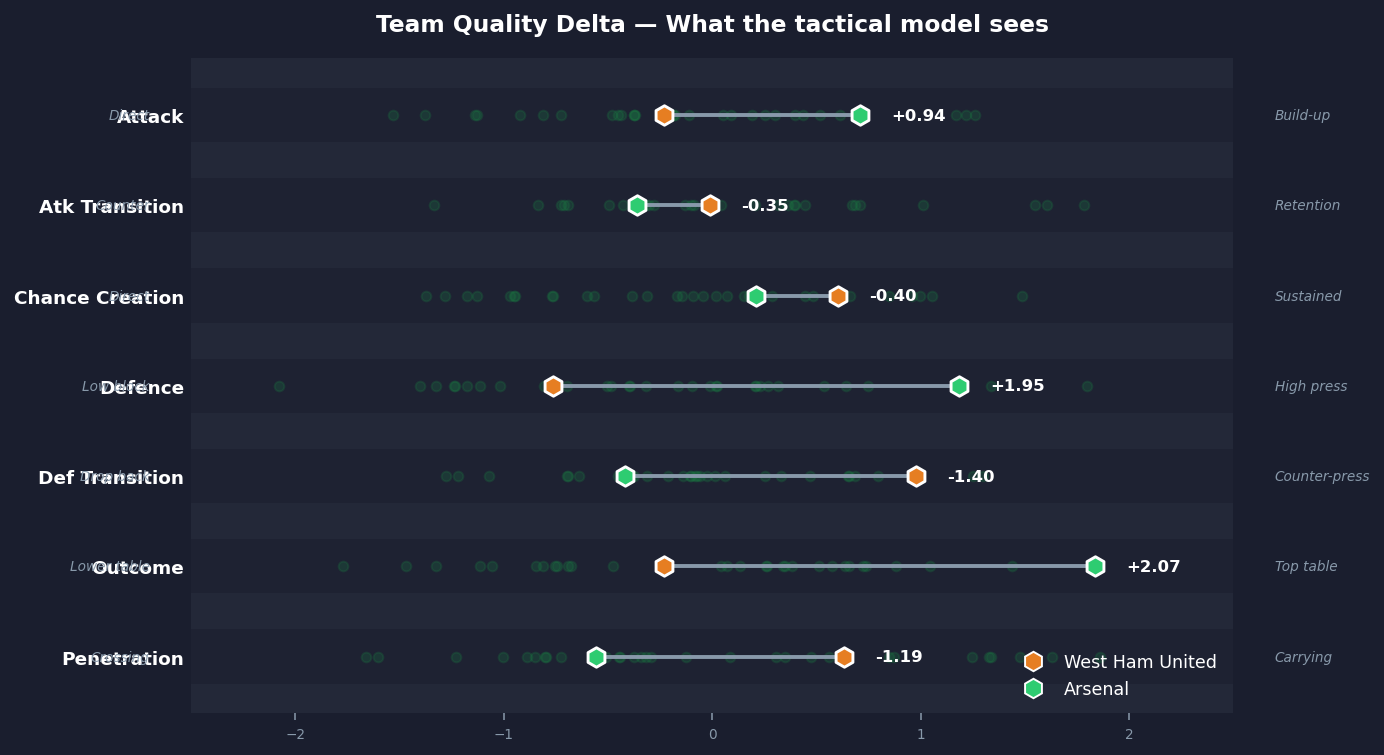

In [11]:
# ── Team Quality Deltas: single Twelve-style plot ──
def plot_tq_delta_single(row, team_map):
    from_team = team_map.get(row['from_team_id'], '?')
    to_team   = team_map.get(row['to_team_id'], '?')

    DARK_BG   = '#1a1e2e'
    DARK_CARD = '#232838'
    GREEN     = '#2ecc71'
    GREEN_DIM = '#1a7a42'
    ORANGE    = '#e67e22'
    WHITE     = '#ffffff'
    GREY      = '#8899aa'

    fig, ax = plt.subplots(figsize=(10, 5.5))
    fig.set_facecolor(DARK_BG)
    ax.set_facecolor(DARK_CARD)

    for i, tq in enumerate(ALL_TQ):
        fr = row['from_q_proj_' + tq]
        to = row['to_q_' + tq]
        delta = to - fr

        # Background strip
        ax.barh(i, 5, left=-2.5, height=0.6, color=DARK_BG, alpha=0.5, zorder=0)

        # Dot cloud (population)
        np.random.seed(42 + i)
        pop = np.random.normal(0, 0.8, 30)
        pop = np.clip(pop, -2.3, 2.3)
        ax.scatter(pop, [i]*len(pop), color=GREEN_DIM, s=25, alpha=0.25, zorder=1)

        # Connector line
        ax.plot([fr, to], [i, i], color=GREY, linewidth=2, solid_capstyle='round', zorder=2)

        # Origin team marker
        ax.scatter(fr, i, color=ORANGE, s=100, zorder=3,
                   edgecolors=WHITE, linewidth=1.5, marker='h')
        # Destination team marker
        ax.scatter(to, i, color=GREEN, s=100, zorder=3,
                   edgecolors=WHITE, linewidth=1.5, marker='h')

        # Delta label
        sign = '+' if delta >= 0 else ''
        x_label = max(fr, to) + 0.15
        ax.text(x_label, i, f'{sign}{delta:.2f}', va='center', ha='left',
                fontsize=8.5, fontweight='bold', color=WHITE)

        # Style labels
        left, right = STYLE_LABELS[tq]
        ax.text(-2.7, i, left, ha='right', va='center', fontsize=7, color=GREY, style='italic')
        ax.text(2.7, i, right, ha='left', va='center', fontsize=7, color=GREY, style='italic')

    ax.set_yticks(range(len(ALL_TQ)))
    ax.set_yticklabels(TQ_DISPLAY, fontsize=9.5, fontweight='bold', color=WHITE)
    ax.set_xlim(-2.5, 2.5)
    ax.invert_yaxis()
    ax.tick_params(axis='x', colors=GREY, labelsize=7)
    ax.tick_params(axis='y', length=0)
    for spine in ax.spines.values(): spine.set_visible(False)

    # Legend
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker='h', color='w', markerfacecolor=ORANGE,
               markersize=10, markeredgecolor=WHITE, label=from_team, linewidth=0),
        Line2D([0], [0], marker='h', color='w', markerfacecolor=GREEN,
               markersize=10, markeredgecolor=WHITE, label=to_team, linewidth=0),
    ]
    ax.legend(handles=handles, loc='lower right', fontsize=9,
              frameon=False, labelcolor=WHITE)

    ax.set_title('Team Quality Delta — What the tactical model sees',
                 fontsize=12, fontweight='bold', color=WHITE, pad=14)
    plt.tight_layout()
    plt.show()

# Example: Declan Rice (West Ham → Arsenal)
rice = mf[mf['wy_player_id'] == 379209].iloc[0]
plot_tq_delta_single(rice, team_map)

---
## Actual vs Predicted — Baseline vs Tactical

For the 3 qualities where tactical context helps most (Involvement, Passing Quality,
Providing Teammates): scatter plots comparing how Baseline (M1) and Tactical (M2)
predictions align with actual values.

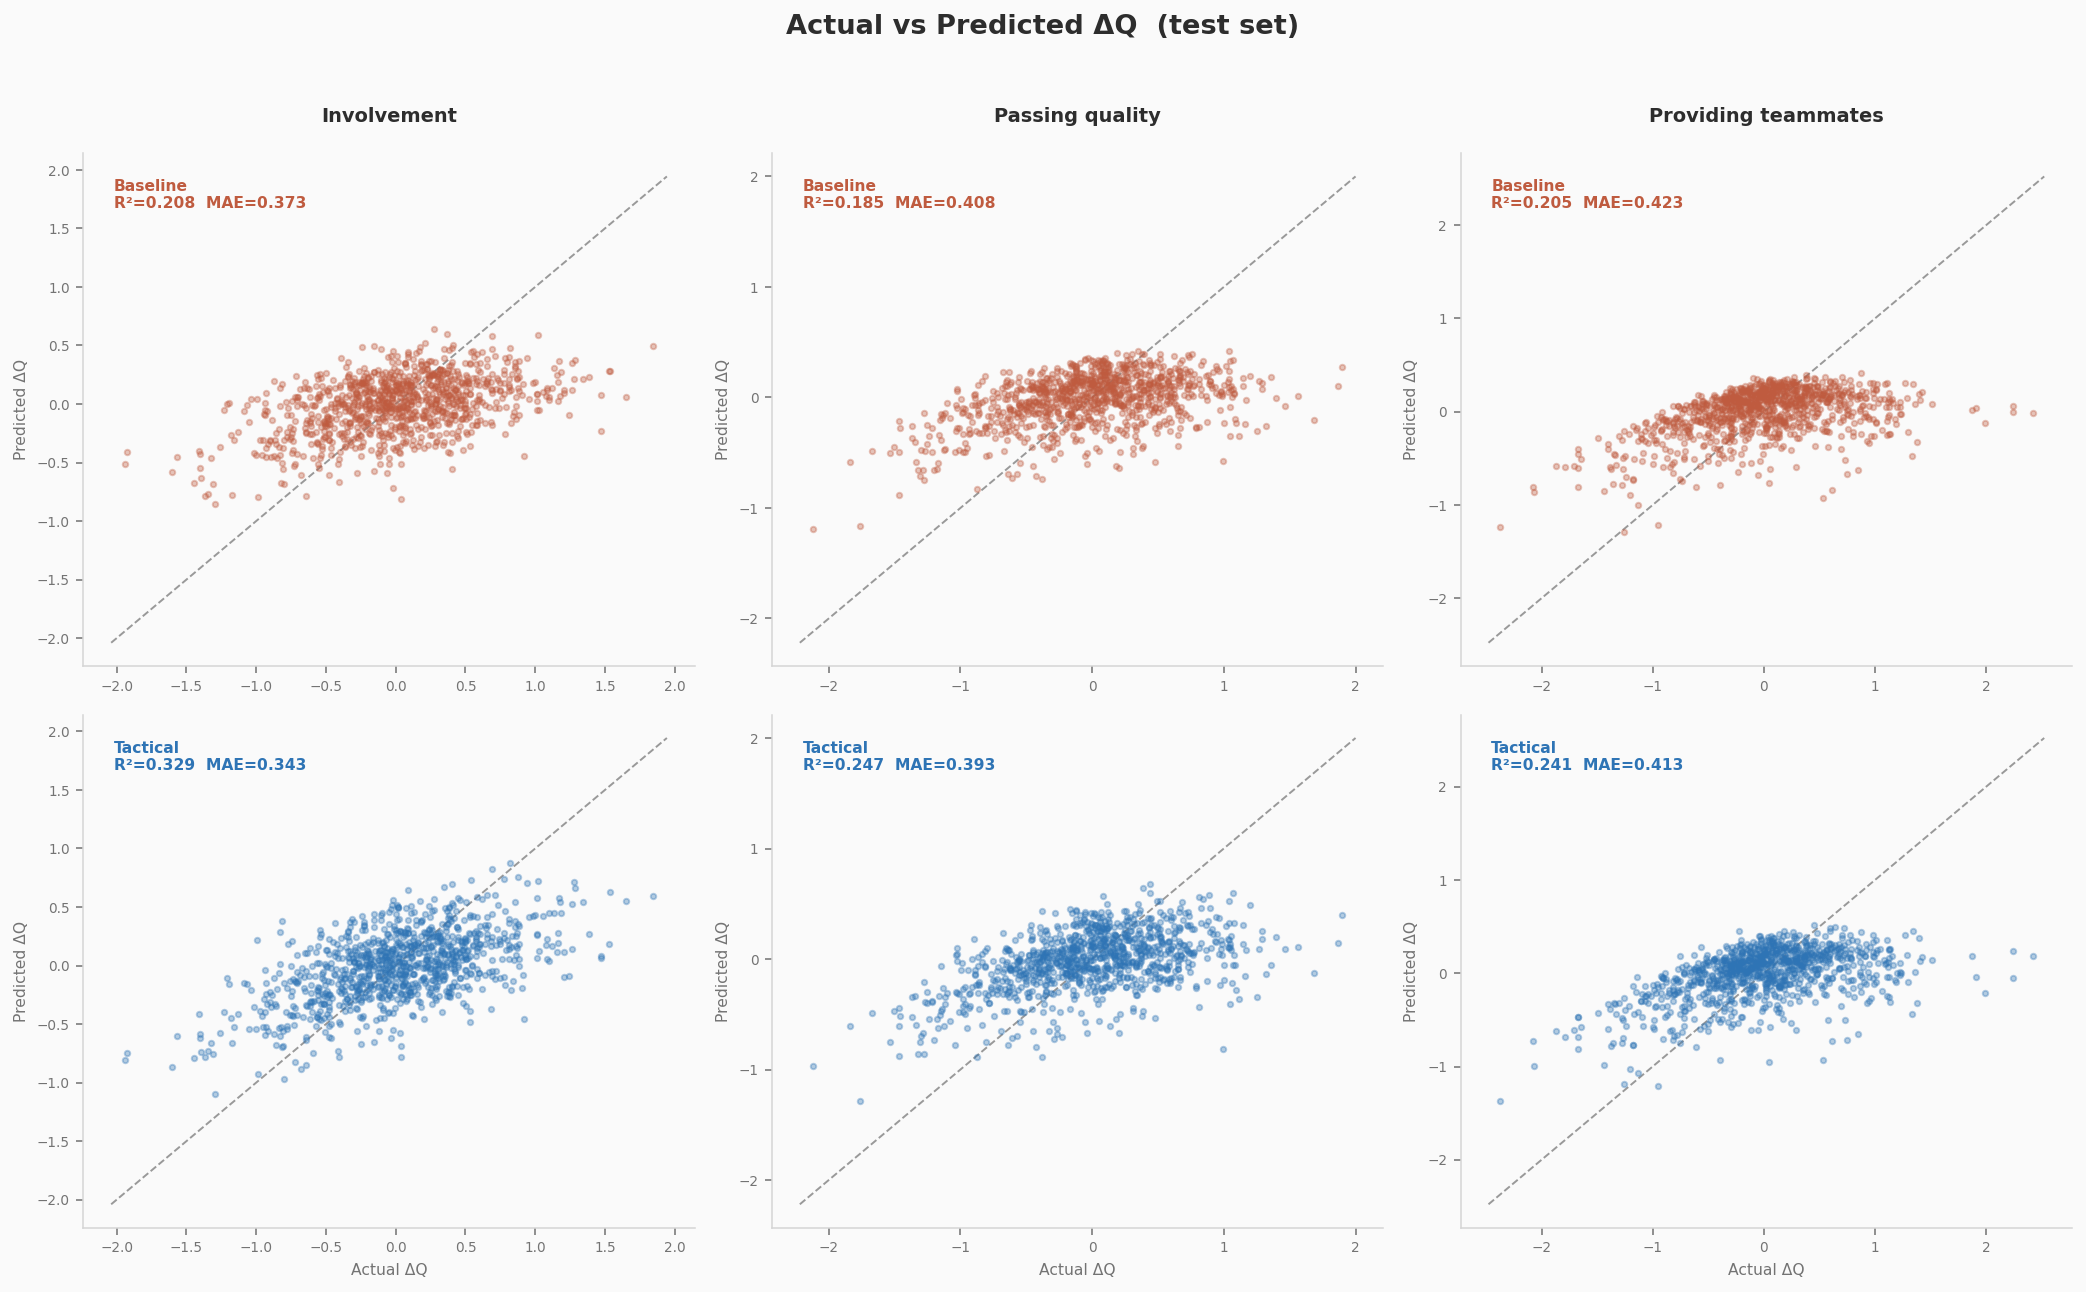

In [12]:
# ── Actual vs Predicted: M1 vs M2 for top-3 improvement qualities ──
TOP_Q = ['Involvement', 'Passing quality', 'Providing teammates']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Actual vs Predicted ΔQ  (test set)',
             fontsize=14, fontweight='bold', color=TEXT, y=1.02)

for col, q in enumerate(TOP_Q):
    bm = best_models[q]
    y_actual = test['delta_' + q].values

    # ── Row 0: Baseline (M1) ──
    ax = axes[0, col]
    X_base = sm.add_constant(test[['from_' + q]])
    y_base = bm['naive'].predict(X_base).values

    ax.scatter(y_actual, y_base, s=8, alpha=0.35, color=C_BASELINE, zorder=2)
    lo = min(y_actual.min(), y_base.min()) - 0.1
    hi = max(y_actual.max(), y_base.max()) + 0.1
    ax.plot([lo, hi], [lo, hi], color='#999999', linewidth=1, linestyle='--', zorder=1)

    r2 = r2_score(y_actual, y_base)
    mae = mean_absolute_error(y_actual, y_base)
    ax.set_title(q, fontsize=10, fontweight='bold')
    ax.text(0.05, 0.95, f'Baseline\nR²={r2:.3f}  MAE={mae:.3f}',
            transform=ax.transAxes, va='top', fontsize=8, color=C_BASELINE, fontweight='bold')
    ax.set_ylabel('Predicted ΔQ', fontsize=8)
    ax.tick_params(labelsize=7)

    # ── Row 1: Tactical (M2) ──
    ax = axes[1, col]
    feat = ['from_' + q] + ['delta_tq_' + d for d in bm['deltas']]
    X_tact = sm.add_constant(test[feat])
    y_tact = bm['tactical'].predict(X_tact).values

    ax.scatter(y_actual, y_tact, s=8, alpha=0.35, color=C_TACTICAL, zorder=2)
    lo = min(y_actual.min(), y_tact.min()) - 0.1
    hi = max(y_actual.max(), y_tact.max()) + 0.1
    ax.plot([lo, hi], [lo, hi], color='#999999', linewidth=1, linestyle='--', zorder=1)

    r2 = r2_score(y_actual, y_tact)
    mae = mean_absolute_error(y_actual, y_tact)
    ax.text(0.05, 0.95, f'Tactical\nR²={r2:.3f}  MAE={mae:.3f}',
            transform=ax.transAxes, va='top', fontsize=8, color=C_TACTICAL, fontweight='bold')
    ax.set_xlabel('Actual ΔQ', fontsize=8)
    ax.set_ylabel('Predicted ΔQ', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

---## Prediction Examples — Full Quality ProfileThree transfer scenarios:- **Lower → Higher table**: Declan Rice (West Ham → Arsenal)- **Higher → Lower table**: Saúl Ñíguez (Atlético Madrid → Sevilla)- **Similar level**: Hakan Çalhanoğlu (Milan → Inter)For each player: the full 8-quality midfielder profile.Dots = actual (pre & post), Star = model prediction.

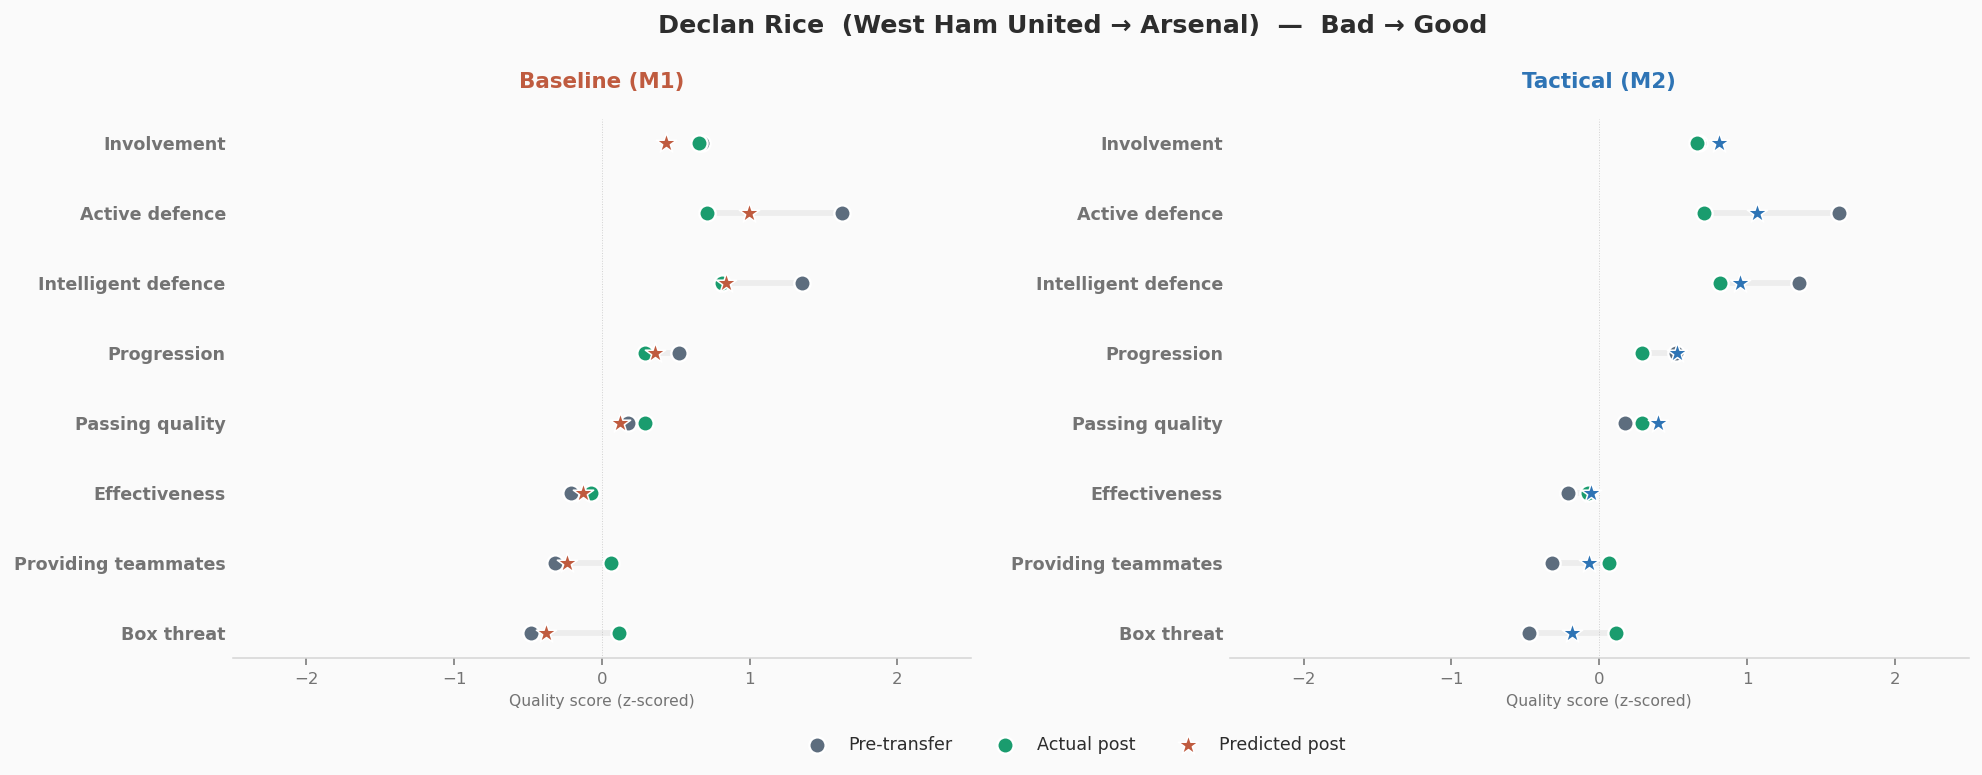

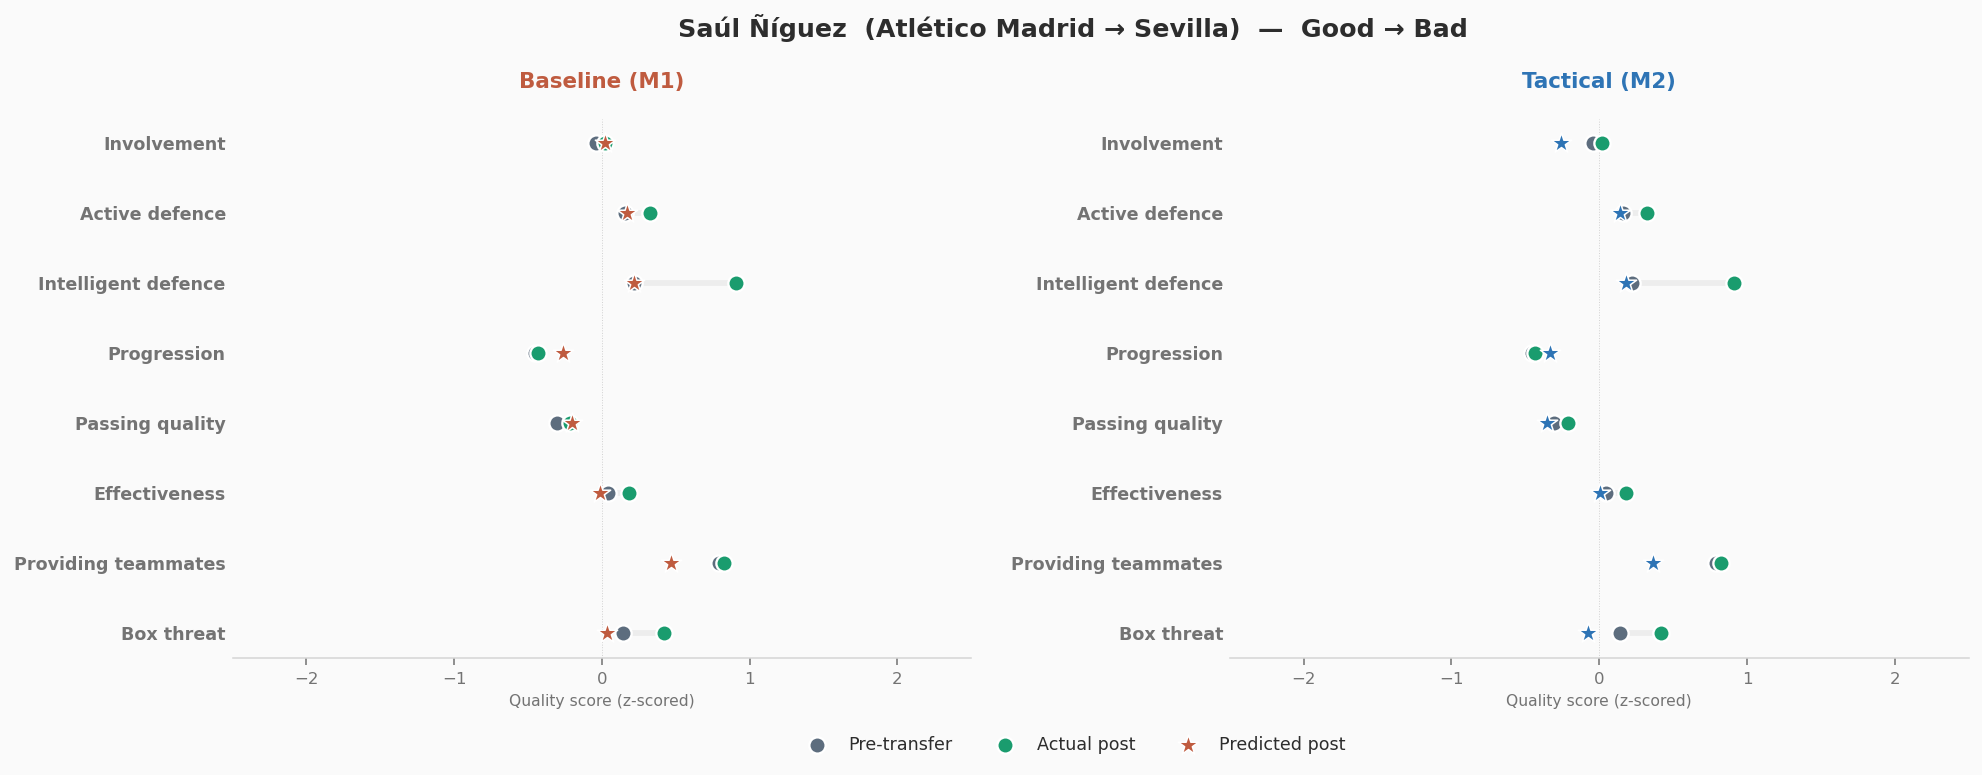

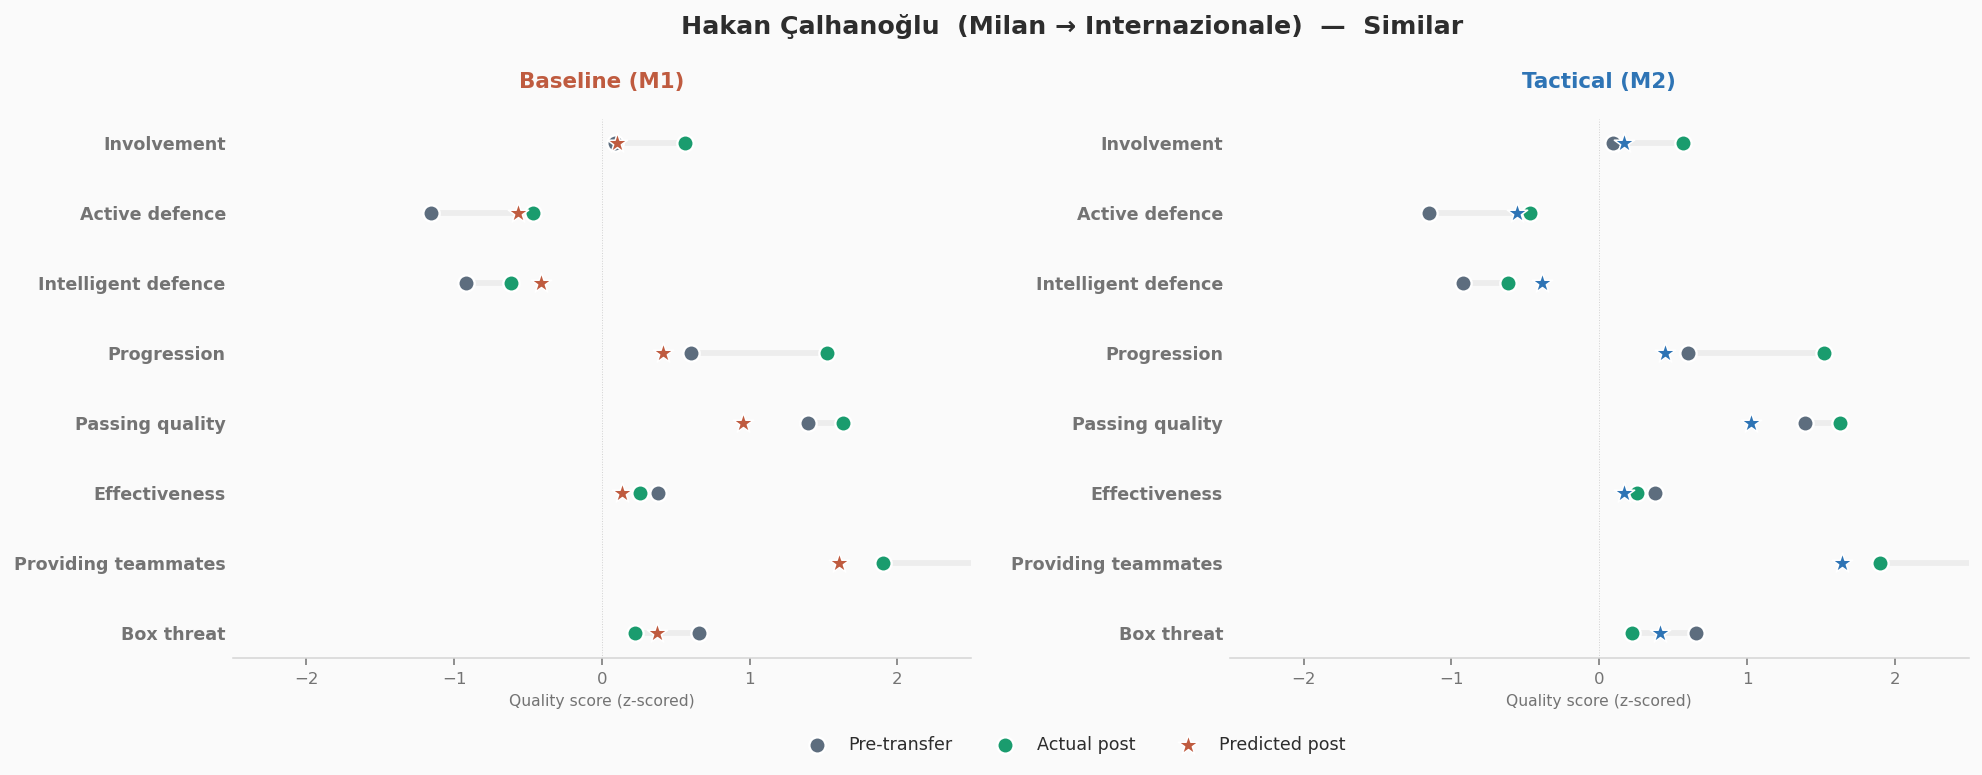

In [13]:
# ── Full 8-quality profile: M1 vs M2 per player ──CASE_PLAYERS = [    (379209, 'Declan Rice',        'Lower → Higher table'),    (4488,   'Saúl Ñíguez',        'Higher → Lower table'),    (15524,  'Hakan Çalhanoğlu',    'Similar'),]for pid, name, scenario in CASE_PLAYERS:    row = mf[mf['wy_player_id'] == pid]    if len(row) == 0:        print(f'Not found: {name}')        continue    row = row.iloc[0]    from_team = team_map.get(row['from_team_id'], '?')    to_team   = team_map.get(row['to_team_id'], '?')    # Compute predictions for all 8 qualities    pre_vals, post_vals, base_pred, tact_pred = [], [], [], []    for q in QUALITIES:        bm = best_models[q]        pre_v  = row['from_' + q]        post_v = row['to_' + q]        # Baseline        xb = pd.DataFrame({'const': [1.0], 'from_' + q: [pre_v]})        pred_b = pre_v + bm['naive'].predict(xb)[0]        # Tactical        td = {'const': [1.0], 'from_' + q: [pre_v]}        for d in bm['deltas']:            td['delta_tq_' + d] = [row['delta_tq_' + d]]        pred_t = pre_v + bm['tactical'].predict(pd.DataFrame(td))[0]        pre_vals.append(pre_v)        post_vals.append(post_v)        base_pred.append(pred_b)        tact_pred.append(pred_t)    # ── Figure: two panels (M1, M2) ──    fig, axes = plt.subplots(1, 2, figsize=(16, 5),                            gridspec_kw={'wspace': 0.35})    fig.suptitle(f'{name}  ({from_team} → {to_team})  —  {scenario}',                 fontsize=13, fontweight='bold', y=1.03)    for ax_idx, (model_name, preds, color) in enumerate([        ('Baseline (M1)', base_pred, C_BASELINE),        ('Tactical (M2)', tact_pred, C_TACTICAL),    ]):        ax = axes[ax_idx]        ax.set_title(model_name, fontsize=11, fontweight='bold', color=color)        for i, q in enumerate(QUALITIES):            pre  = pre_vals[i]            post = post_vals[i]            pred = preds[i]            # Line from pre to post (actual trajectory)            ax.plot([pre, post], [i, i], color=GRID, linewidth=3,                    solid_capstyle='round', zorder=1)            # Pre dot            ax.scatter(pre, i, color=C_PRE, s=70, zorder=3,                       edgecolors='white', linewidth=1.2,                       label='Pre-transfer' if i == 0 and ax_idx == 0 else '')            # Actual post dot            ax.scatter(post, i, color=C_POST, s=70, zorder=3,                       edgecolors='white', linewidth=1.2,                       label='Actual post' if i == 0 and ax_idx == 0 else '')            # Predicted post star            ax.scatter(pred, i, color=color, s=120, zorder=4,                       marker='*', edgecolors='white', linewidth=0.8,                       label='Predicted post' if i == 0 and ax_idx == 0 else '')        ax.set_yticks(range(len(QUALITIES)))        ax.set_yticklabels(QUALITIES, fontsize=9, fontweight='bold')        ax.invert_yaxis()        ax.set_xlim(-2.5, 2.5)        ax.axvline(0, color=SUBTEXT, linewidth=0.5, linestyle=':', alpha=0.3)        ax.set_xlabel('Quality score (z-scored)', fontsize=8)        ax.spines['left'].set_visible(False)        ax.spines['top'].set_visible(False)        ax.spines['right'].set_visible(False)        ax.tick_params(axis='y', length=0)    # Legend    handles, labels = axes[0].get_legend_handles_labels()    if handles:        fig.legend(handles, labels, loc='lower center', ncol=3,                   fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.05))    plt.tight_layout()    plt.show()